In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

In [2]:
arrests_df = pd.read_csv('UsArrests.csv')
arrests_df.head()

,City,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [3]:
arrests_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   City      50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [4]:
arrests_df.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [5]:
arrests_df.isnull().sum()

City        0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

### Data Distribution  
Most variables don't follow a Gaussian distribution.  
Values will be standardized.

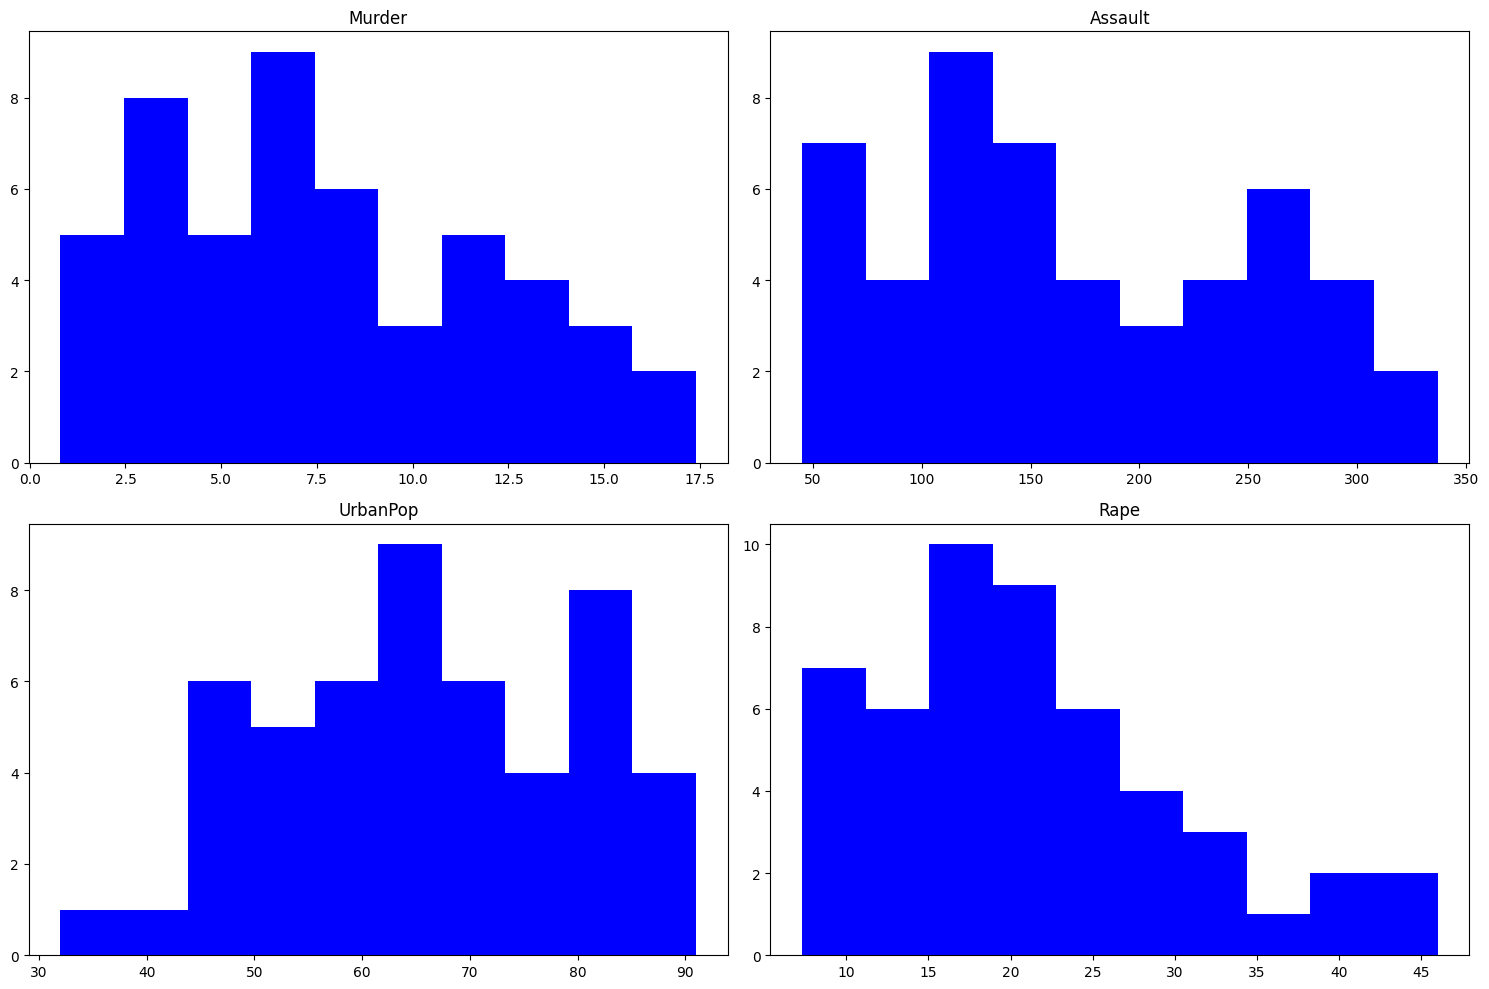

In [6]:
histograms = arrests_df.hist(color='blue', grid=False, figsize=(15, 10))
plt.tight_layout()
plt.show()

### Correlation Analysis
**Murder VS Assault - 0.80**  
Strong positive correlation  
**Assault VS Rape - 0.67**  
Moderate to strong correlation  
**Murder VS Rape - 0.56**  
Moderate correlation  
  
**UrbanPop shows weak correlations with the other variables:**  
VS Murder - 0.07  
VS Assault - 0.26  
VS Rape - 0.41   
  
Violent crime variables (Murder, Assault, Rape) are strongly related and likely measure a common underlying factor (overall violent crime).
Urban population behaves differently.  
This confirms multicollinearity, some variables are redundant.

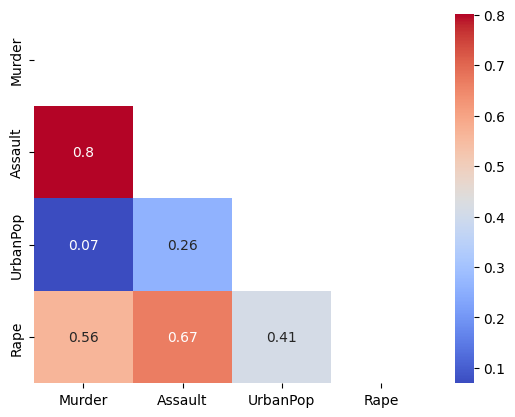

In [8]:
corr_df = arrests_df.drop(["City"],axis=1).corr()
mask_ut=np.triu(np.ones(corr_df.shape)).astype(np.bool)
sns.heatmap(corr_df, mask=mask_ut, annot=True, cmap="coolwarm")
plt.show()

In [35]:
X = arrests_df.drop('City', axis=1)
scaler = StandardScaler()
pca = PCA()

X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca[:,0:2], columns=["PC1","PC2"])
pca_df.head()

,PC1,PC2
0,0.985566,-1.133392
1,1.950138,-1.073213
2,1.763164,0.745957
3,-0.141420,-1.119797
4,2.523980,1.542934


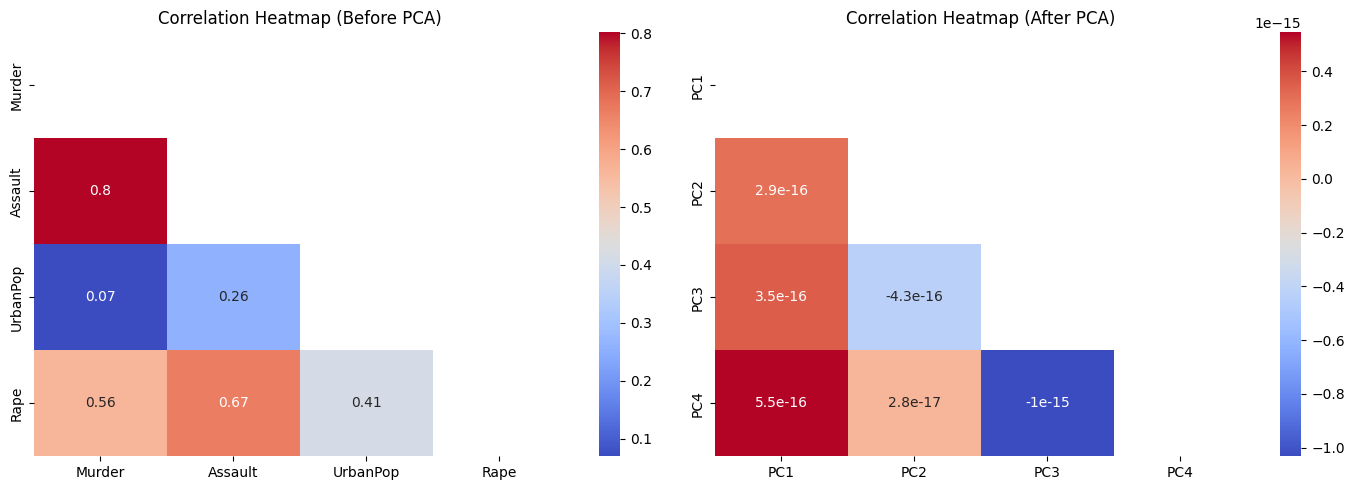

In [32]:
corr_after = pca_df.corr()
mask_after = np.triu(np.ones(corr_after.shape)).astype(np.bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before PCA
sns.heatmap(corr_df, mask=mask_ut, cmap="coolwarm", annot=True, ax=axes[0])
axes[0].set_title("Correlation Heatmap (Before PCA)")

# After PCA
sns.heatmap(corr_after, mask=mask_after, cmap="coolwarm", annot=True, ax=axes[1])
axes[1].set_title("Correlation Heatmap (After PCA)")

plt.tight_layout()
plt.show()

In [36]:
def biplot(scores, loadings, feature_names, city):
    xs = scores[:, 0]
    ys = scores[:, 1]

    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    fig, ax = plt.subplots(figsize=(8,6))

    # Scatter plot colored by city
    for sp in np.unique(city):
        mask = city == sp
        ax.scatter(xs[mask] * scalex, ys[mask] * scaley, label=sp, alpha=0.7)

    # Plot feature vectors (loadings)
    for i, feature in enumerate(feature_names):
        ax.arrow(
            0, 0,
            loadings[i, 0],
            loadings[i, 1],
            head_width=0.03,
            color="red",
            alpha=0.7
        )
        ax.text(
            loadings[i, 0] * 1.15,
            loadings[i, 1] * 1.15,
            feature,
            color="green",
            ha="center",
            va="center"
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("PCA Biplot (US Arrests Dataset)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), ncol=3)
    ax.grid(True)

    plt.show()

### Biplot of First Two Components  
**The red arrows indicate variable vectors:**  
Murder, Assault point in similar directions    
Strongly positively correlated  
Rape also aligns with PC1 but slightly differently  
  
UrbanPop loads more heavily on PC2, nearly independent to Murder/Assault  
  
PC1 - overall violent crime intensity  
High loadings from Murder, Assault, Rape  
  
PC2 - urbanization effect  
Dominated by UrbanPop

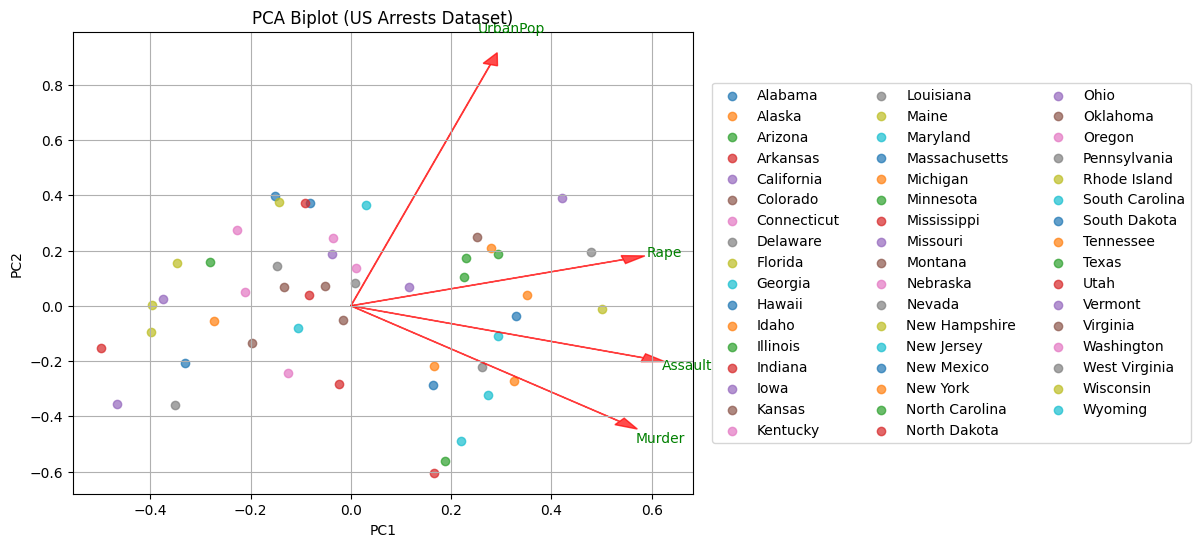

In [37]:
biplot(X_pca[:, :2], pca.components_[:2, :].T, X.columns.tolist(), arrests_df['City'].values)

### Number of Principal Components  
**The standard PCA results reveal the following:**  
PC1 explains about 62–63% of variance  
PC2 explains about 24–25% of variance  
PC1 + PC2 is about 87% of total variance  

The curve on Scree plot bends when the number of components is about 2, therefore 2 principal components are appropriate.

In [34]:
pca.explained_variance_ratio_ * 100

array([62.00603948, 24.74412881,  8.91407951,  4.33575219])

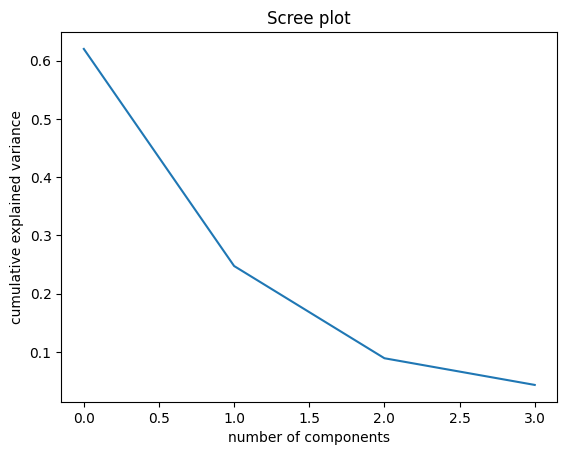

In [33]:
# Scree plot
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.title("Scree plot")
plt.show()

### Hierarchical Clustering Analysis  
Hierarchical clustering using both average and complete linkage was applied to the PCA-reduced data.  
The average linkage method produced balanced clusters with gradual merging.  
The complete linkage resulted in tighter and more clearly separated clusters.  
Both methods identified broadly similar groupings of cities, indicating a stable cluster structure.  
Cities within the same cluster exhibited comparable violent crime profiles, particularly in terms of murder, assault, and rape rates, with urban population acting as a secondary differentiating factor.

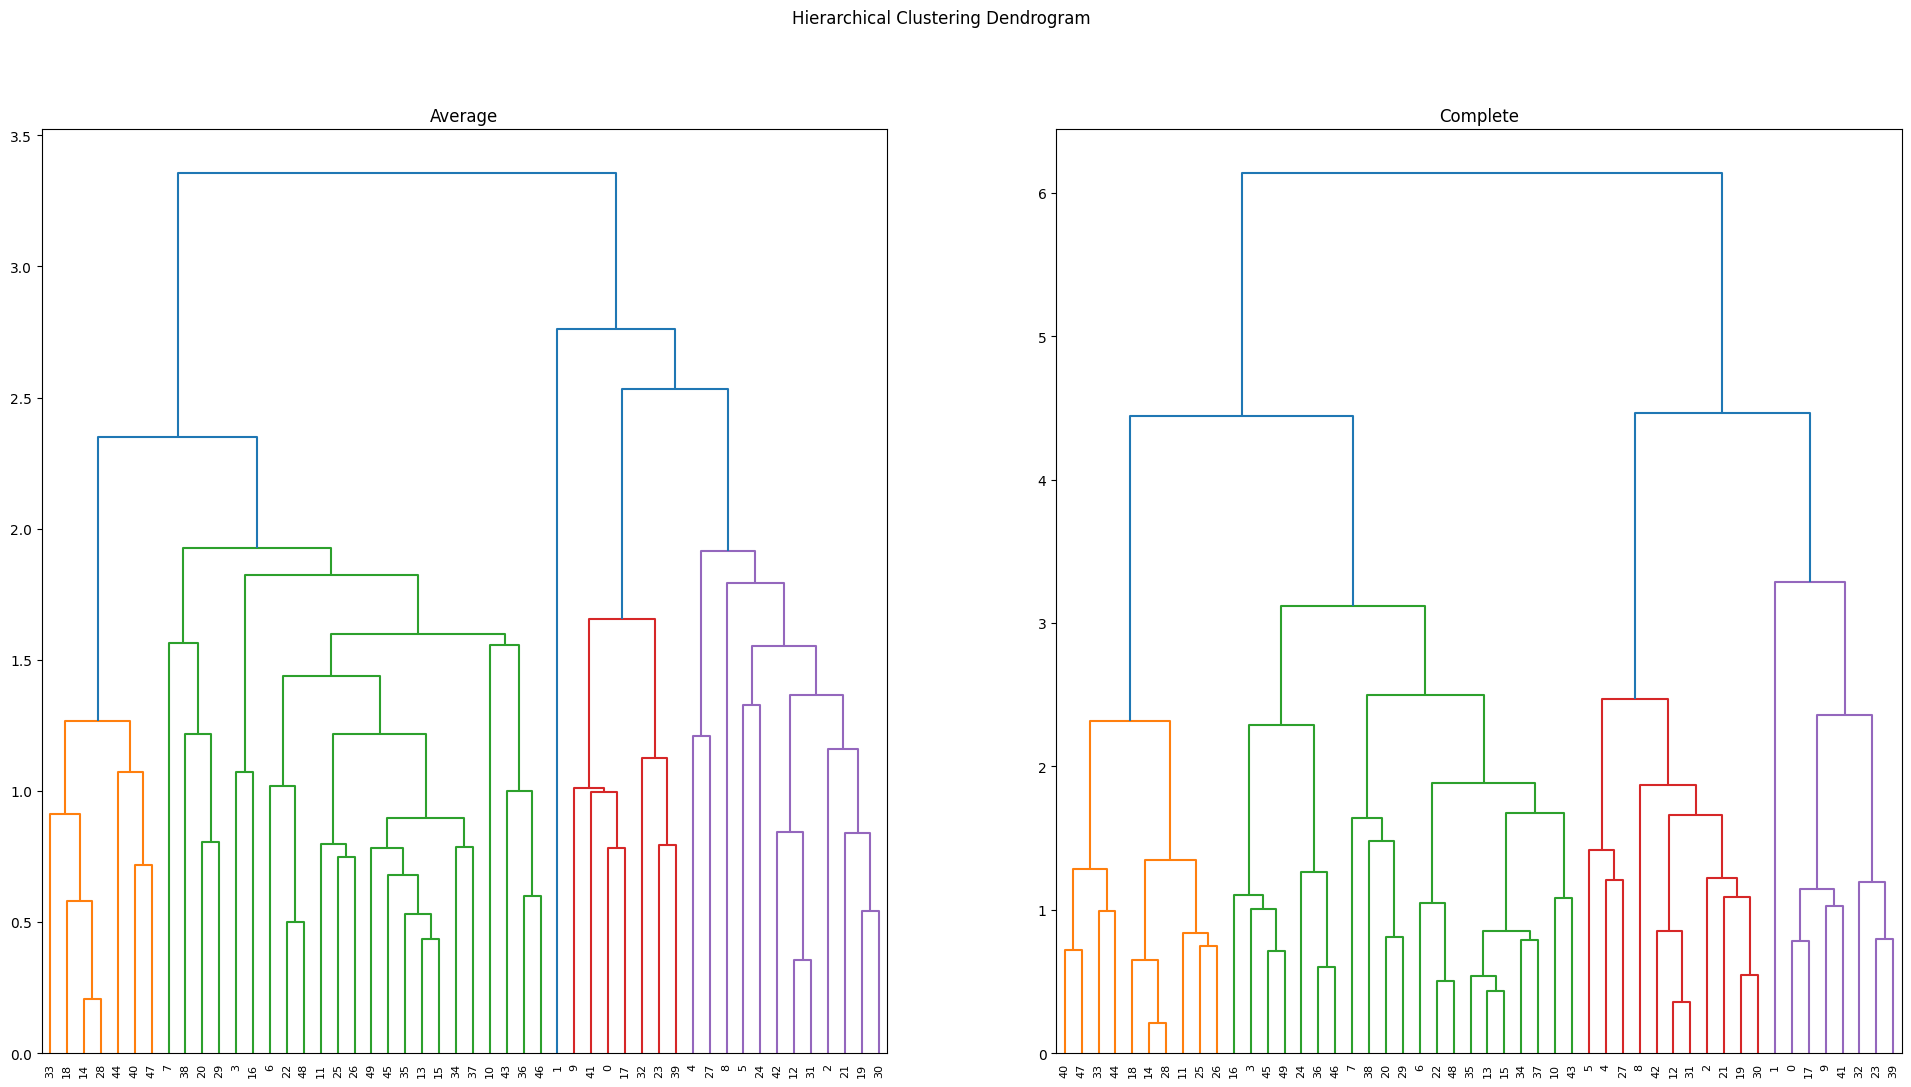

In [30]:
linked = linkage(X_pca, method="average")

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(24, 12))
fig.suptitle('Hierarchical Clustering Dendrogram')

ax1.set_title("Average")
dendrogram(linkage(pca_df, method='average'), labels=pca_df.index, ax=ax1)
ax2.set_title("Complete")
dendrogram(linkage(pca_df, method='complete'), labels=pca_df.index, ax=ax2)
plt.show()

### K-means Clustering Analysis  
The K-means clustering applied to the first two principal components reveals three distinct crime profiles among U.S. cities.  
The first cluster consists of cities with consistently low crime rates.  
The second cluster represents cities with moderate crime levels.  
The third cluster has cities with high violent crime intensity.  
The clear separation along the first principal component indicates that overall crime magnitude is the primary driver of clustering, with centroids confirming compact and interpretable groupings.

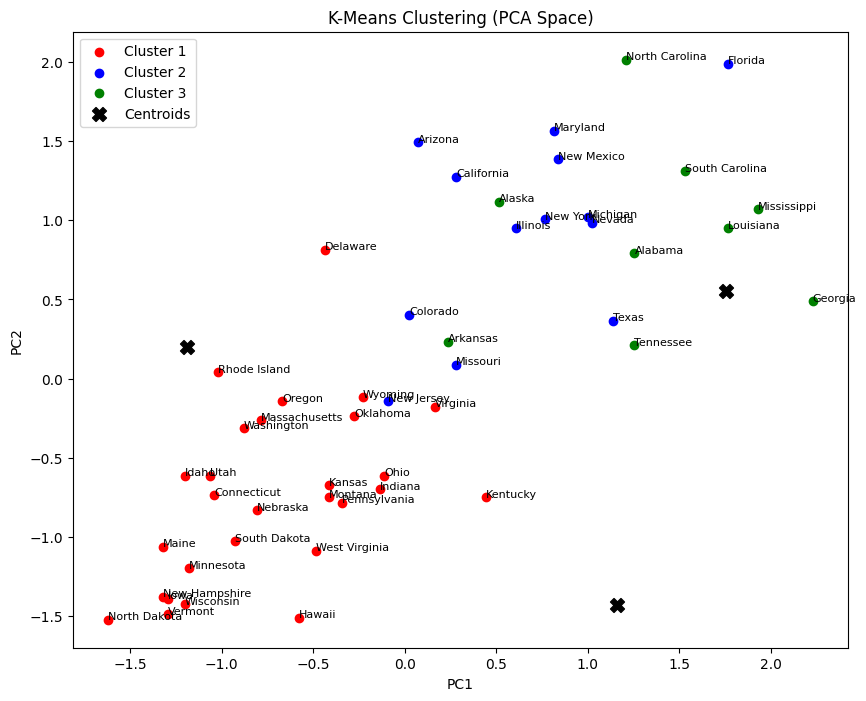

In [38]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Extract first two PCA components
x = X_scaled[:,0]
y = X_scaled[:,1]

# Fit K-Means
k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(pca_df)
centroids = kmeans.cluster_centers_

# Plot K-Means clusters
fig, ax = plt.subplots(figsize=(10,8))
colours = ['r','b','g']

for i in range(0,k):
    ax.scatter(x[kmeans_labels == i],
               y[kmeans_labels == i],
               c=colours[i],
               label=f'Cluster {i+1}')

# Plot centroids
ax.scatter(centroids[:,0], centroids[:,1],
           c='black', marker='X', s=100, label='Centroids')

# Annotate points
for i in range(len(x)):
    ax.annotate(arrests_df['City'][i], (x[i], y[i]), fontsize=8)

ax.set_title("K-Means Clustering (PCA Space)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.show()
